# Atelier – Préparation de Données Textuelles

## Structure du projet

In [2]:
import os

# Racine du projet = dossier contenant data/ et notebooks/
PROJECT_ROOT = os.path.abspath(os.getcwd())
if not os.path.isdir(os.path.join(PROJECT_ROOT, "data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(PROJECT_ROOT, ".."))

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
NOTEBOOKS_DIR = os.path.join(PROJECT_ROOT, "notebooks")

for d in [DATA_DIR, NOTEBOOKS_DIR]:
    os.makedirs(d, exist_ok=True)

Import des bibliothèques nécessaires et chargement du fichier `smart_reviews_raw.csv` depuis `data/`

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

RAW_PATH = os.path.join(DATA_DIR, "smart_reviews_raw.csv")
df = pd.read_csv(RAW_PATH)
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr


## Partie 1 – Exploration du corpus

### 1) Charger les données CSV

In [4]:
print(f"Fichier chargé : {RAW_PATH}")
df.info()

Fichier chargé : /Users/fsarr/Documents/atelier_prepa_donnees_textuelles-/data/smart_reviews_raw.csv
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_avis    1200 non-null   str  
 1   date       1200 non-null   str  
 2   source     1200 non-null   str  
 3   produit    1200 non-null   str  
 4   texte      1195 non-null   str  
 5   sentiment  1200 non-null   str  
 6   note       1200 non-null   int64
 7   langue     1200 non-null   str  
dtypes: int64(1), str(7)
memory usage: 75.1 KB


### 2)Combien d'avis contient le dataset ?

In [5]:
nb_avis = df.shape[0]
print(f"Nombre d'avis : {nb_avis}")


Nombre d'avis : 1200


### 3) Combien de colonnes possède-t-il ?

In [6]:
nb_colonnes = df.shape[1]
print(f"Nombre de colonnes : {nb_colonnes}")
print("Colonnes :", list(df.columns))

Nombre de colonnes : 8
Colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### 4) Quel est le type de chaque colonne ?

In [7]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ?

In [8]:
na_counts = df.isna().sum()
print(na_counts)
print(f"\nTotal de valeurs manquantes : {na_counts.sum()}")

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

Total de valeurs manquantes : 5


### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères.

In [9]:
def show_example(mask, label, n=1):
    exemples = df.loc[mask, "texte"].dropna()
    print(f"--- {label} ({mask.sum()} occurrence(s)) ---")
    if len(exemples) > 0:
        for t in exemples.head(n):
            print(repr(t))
    else:
        print("(aucun exemple trouvé)")
    print()

texte = df["texte"].fillna("")

show_example(texte.str.strip().eq("") | df["texte"].isna(), "Texte vide")
show_example(texte.str.contains(r"https?://|www\.", regex=True), "Texte avec URL")
show_example(texte.str.contains(r"@\w+", regex=True), "Texte avec mention")
show_example(texte.str.contains(r"#\w+", regex=True), "Texte avec hashtag")
show_example(texte.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", regex=True), "Texte avec emojis")
show_example(texte.str.count(r"[!?.,]{3,}").gt(0), "Texte avec beaucoup de ponctuation")
show_example(texte.str.len().gt(0) & texte.eq(texte.str.upper()) & texte.str.contains(r"[A-Za-zÀ-ÿ]"), "Texte en majuscules")
mask_repetition = texte.apply(lambda t: bool(re.search(r"(.)\1{2,}", t)))
show_example(mask_repetition, "Texte avec répétition de caractères")

# Un exemple de texte "normal" (aucun des cas ci-dessus)
mask_special = texte.str.contains(r"https?://|www\.|@\w+|#\w+|[\U0001F300-\U0001FAFF\u2600-\u27BF]", regex=True)
mask_normal = ~(mask_special | mask_repetition) & texte.str.len().gt(0)
show_example(mask_normal & texte.str.len().gt(0), "Texte normal")


--- Texte vide (6 occurrence(s)) ---
'   '

--- Texte avec URL (143 occurrence(s)) ---
'Produit parfait, rien à signaler. https://example.com/commande/17'

--- Texte avec mention (128 occurrence(s)) ---
'@client Livraison rapide et produit conforme à mes attentes.'

--- Texte avec hashtag (127 occurrence(s)) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec emojis (192 occurrence(s)) ---
'Très satisfait de mon achat 👍 #avis'

--- Texte avec beaucoup de ponctuation (141 occurrence(s)) ---
'Produit excellent, je suis très satisfait. !!!'

--- Texte en majuscules (146 occurrence(s)) ---
"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

--- Texte avec répétition de caractères (165 occurrence(s)) ---
'Produit excellent, je suis très satisfait. !!!'

--- Texte normal (482 occurrence(s)) ---
'Très  bonne  expérience,  simple  et  efficace.'



### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [12]:
df["longueur"] = df["texte"].fillna("").str.len()

stats_longueur = df["longueur"].describe(percentiles=[0.25, 0.5, 0.75])
print(stats_longueur)

print(f"\nLongueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne  : {df['longueur'].mean():.2f}")
print(f"Longueur médiane  : {df['longueur'].median()}")
print(f"Q1 / Q3           : {df['longueur'].quantile(0.25)} / {df['longueur'].quantile(0.75)}")


count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 48.96
Longueur médiane  : 48.0
Q1 / Q3           : 37.0 / 56.0


### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions


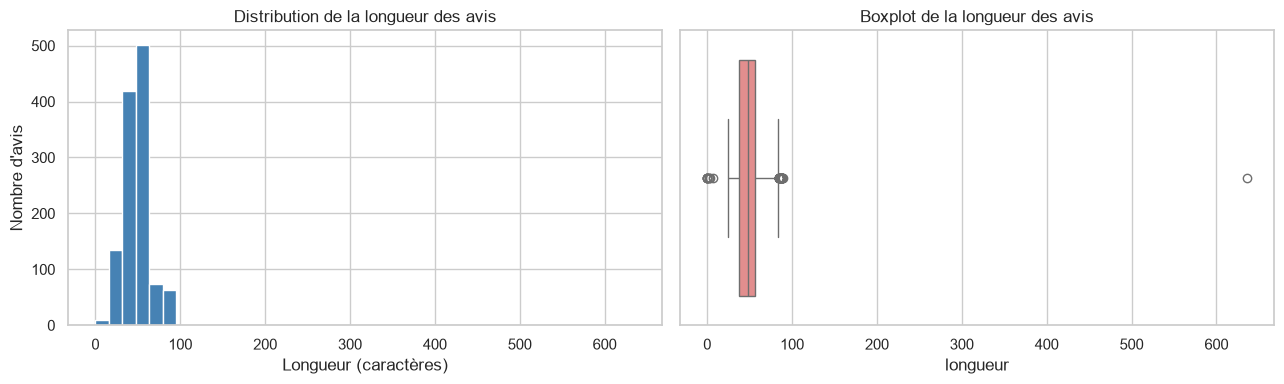

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["longueur"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de la longueur des avis")
axes[0].set_xlabel("Longueur (caractères)")
axes[0].set_ylabel("Nombre d'avis")

sns.boxplot(x=df["longueur"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot de la longueur des avis")
plt.tight_layout()
plt.show()

#### a) Existe-t-il des textes anormalement longs ?


In [15]:
#textes anormalement longs (> Q3 + 1.5*IQR, règle classique du boxplot)
q1, q3 = df["longueur"].quantile([0.25, 0.75])
iqr = q3 - q1
seuil_haut = q3 + 1.5 * iqr
nb_longs = (df["longueur"] > seuil_haut).sum()
print(f"Seuil d'anomalie (Q3 + 1.5*IQR) = {seuil_haut:.1f} caractères")
print(f"   -> {nb_longs} textes anormalement longs ({nb_longs/len(df)*100:.1f}% du corpus)")

Seuil d'anomalie (Q3 + 1.5*IQR) = 84.5 caractères
   -> 41 textes anormalement longs (3.4% du corpus)


#### b) Existe-t-il beaucoup de textes très courts ?

In [18]:
#textes très courts (arbitraire : < 10 caractères)
nb_courts = (df["longueur"] < 10).sum()
print(f"\n il y a {nb_courts} textes très courts (< 10 caractères), soit {nb_courts/len(df)*100:.1f}% du corpus")


 il y a 9 textes très courts (< 10 caractères), soit 0.8% du corpus


### 9) Détecter les textes vides

In [19]:
mask_vide = df["texte"].isna() | df["texte"].fillna("").str.strip().eq("")
nb_vides = mask_vide.sum()
print(f"Nombre de textes vides/manquants : {nb_vides}")
df.loc[mask_vide, ["id_avis", "texte"]]


Nombre de textes vides/manquants : 6


,id_avis,texte
46,AV0047,NaN
108,AV0109,NaN
310,AV0311,NaN
640,AV0641,NaN
781,AV0782,NaN
951,AV0952,


### 10) Détecter les doublons sur le texte

In [20]:
mask_doublons = df["texte"].duplicated(keep=False) & df["texte"].notna()
nb_doublons_lignes = df["texte"].duplicated(keep="first").sum()
print(f"Nombre de lignes en doublon (texte identique, en gardant la 1re occurrence) : {nb_doublons_lignes}")
print(f"Nombre total de lignes impliquées dans un doublon : {mask_doublons.sum()}")
df.loc[mask_doublons].sort_values("texte").head(10)


Nombre de lignes en doublon (texte identique, en gardant la 1re occurrence) : 881
Nombre total de lignes impliquées dans un doublon : 1031


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
312,AV0313,2026-04-18,mobile,Écouteurs AirSound,@client Excellent rapport qualité-prix.,positif,4,fr,39
419,AV0420,2026-04-11,sav,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1099,AV1100,2026-06-30,email,Tablette TabPlus,@client Excellent rapport qualité-prix.,positif,5,fr,39
45,AV0046,2026-08-26,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
466,AV0467,2026-07-04,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
1059,AV1060,2026-01-24,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
146,AV0147,2026-08-11,mobile,Ordinateur NovaBook,@client Excellent rapport qualité-prix.,positif,5,fr,39
593,AV0594,2026-06-11,mobile,SmartWatch Pro,@client Excellent rapport qualité-prix.,positif,4,fr,39
611,AV0612,2026-03-02,web,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39
398,AV0399,2026-07-14,email,SmartPhone X,@client Excellent rapport qualité-prix.,positif,5,fr,39


### 11) Les classes sont-elles équilibrées ?

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

sentiment
positif    64.7 %
neutre     20.5 %
negatif    14.8 %
Name: proportion, dtype: str


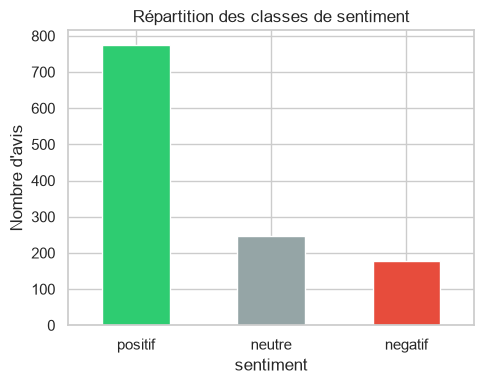


Les classes sont clairement DÉSÉQUILIBRÉES (majorité de 'positif').


In [22]:
repartition = df["sentiment"].value_counts()
repartition_pct = df["sentiment"].value_counts(normalize=True) * 100

print(repartition)
print()
print(repartition_pct.round(1).astype(str) + " %")

plt.figure(figsize=(5, 4))
repartition.plot(kind="bar", color=["#2ecc71", "#95a5a6", "#e74c3c"])
plt.title("Répartition des classes de sentiment")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nLes classes sont clairement DÉSÉQUILIBRÉES (majorité de 'positif').")


### 12) Quelle est la classe majoritaire ?

In [23]:
classe_majoritaire = df["sentiment"].value_counts().idxmax()
part_majoritaire = df["sentiment"].value_counts(normalize=True).max() * 100
print(f"Classe majoritaire : '{classe_majoritaire}' ({part_majoritaire:.1f}% des avis)")


Classe majoritaire : 'positif' (64.7% des avis)


### 13) Quelles métriques de classification à envisager d’utiliser ?

Avec un déséquilibre de classes, l'**accuracy** seule est trompeuse
(un modèle qui prédit toujours "positif" aurait déjà un score élevé).

Métriques à privilégier :
- **F1-score macro** (moyenne non pondérée sur les 3 classes) : traite chaque classe équitablement.
- **Precision / Recall par classe**, notamment sur la classe minoritaire `negatif`.
- **Matrice de confusion** pour visualiser les erreurs entre classes.
- Éventuellement le **F1-score pondéré (weighted)** si l'on veut refléter la distribution réelle, en complément du macro.

In [24]:
# Illustration : comparaison accuracy vs répartition des classes pour un modèle "naïf"
baseline_accuracy = df["sentiment"].value_counts(normalize=True).max()
print(f"Un modèle qui prédit toujours '{classe_majoritaire}' obtiendrait déjà une accuracy de {baseline_accuracy*100:.1f}%.")
print("=> Ne jamais se fier à l'accuracy seule ici : privilégier le F1-score macro et l'analyse par classe.")


Un modèle qui prédit toujours 'positif' obtiendrait déjà une accuracy de 64.7%.
=> Ne jamais se fier à l'accuracy seule ici : privilégier le F1-score macro et l'analyse par classe.
